# Calibrating a Function Generator 
#### Data Visualization and Analysis

In [2]:
import numpy as np
import matplotlib.pyplot as plt

##### Plot Styling Function

In [2]:
def plot_fft_stems(freq_vec, mag_vec, title="FFT Spectrum", x_max=None):
    """
    Plots pre-computed FFT data in an oscilloscope style (Green stems / Black background).
    
    Args:
        freq_vec (np.array): 1D array of pre-calculated frequency values (Hz).
        mag_vec (np.array): 1D array of pre-calculated magnitude values (dB or Linear).
        title (str): Title for the top of the plot.
        x_max (float): Optional limit for the x-axis (Frequency).
    """
    # 1. Determine the dynamic baseline (noise floor)
    bottom_val = np.min(mag_vec)

    # 2. Setup the Dark Mode figure and axis
    plt.figure(figsize=(12, 6), facecolor='black')
    ax = plt.gca()
    ax.set_facecolor('black')

    # 3. Create the Stem Plot
    # bottom=bottom_val ensures stems grow UP from the noise floor
    markerline, stemlines, baseline = plt.stem(freq_vec, mag_vec, bottom=bottom_val)

    # 4. Oscilloscope Styling (Matrix Green)
    plt.setp(stemlines, 'color', '#00FF41', 'linewidth', 1) 
    plt.setp(markerline, 'color', '#00FF41', 'markersize', 3, 'alpha', 0.8)
    plt.setp(baseline, 'visible', False) # Hide the baseline for a cleaner scope look

    # 5. Format labels, grid, and ticks for Dark Mode
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    plt.grid(True, linestyle='--', color='gray', alpha=0.3)

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("Frequency (Hz)", fontweight='bold')
    plt.ylabel("Magnitude", fontweight='bold')
    
    # 6. Dynamic X-Axis Scaling
    if x_max:
        plt.xlim(0, x_max)
    else:
        plt.xlim(0, np.max(freq_vec))
        
    # Add a bit of headroom on the Y-axis
    plt.ylim(bottom_val, np.max(mag_vec) + 5)

    plt.tight_layout()
    plt.show()



#### Plotting Signals from Function Generator

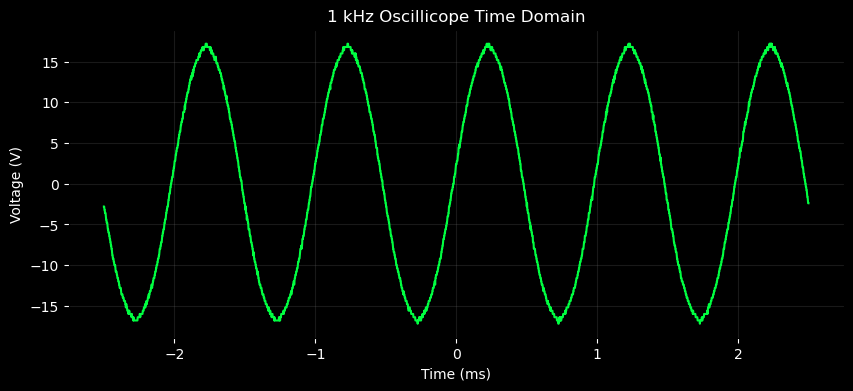

In [3]:
# Load Time Domain data (1k-time.csv)
# Column 3 = Time, Column 4 = Voltage
t_vec = np.genfromtxt('1k-time.csv', delimiter=',', usecols=3)
v_vec = np.genfromtxt('1k-time.csv', delimiter=',', usecols=4)

plt.figure(figsize=(10, 4), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Plotting the 1D vectors
plt.plot(t_vec * 1000, v_vec, color='#00FF41', linewidth=1.5)

# Styling
plt.title("1 kHz Oscillicope Time Domain", color='white')
plt.xlabel("Time (ms)", color='white')
plt.ylabel("Voltage (V)", color='white')
plt.tick_params(colors='white')
plt.grid(True, alpha=0.2, color='gray')
plt.show()

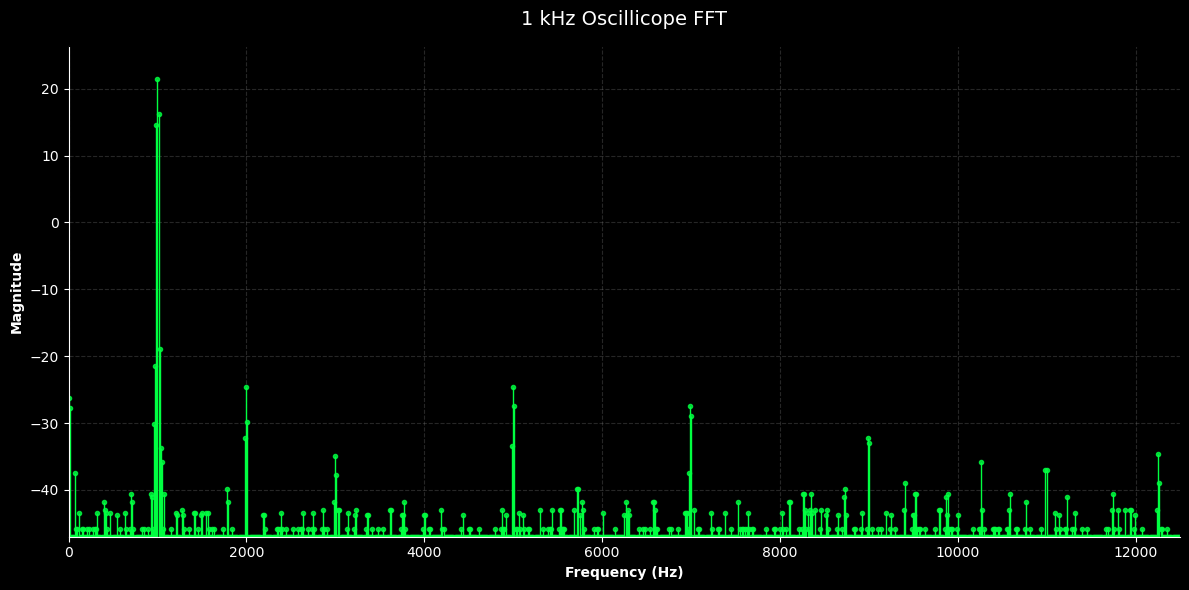

In [4]:
# --- Example Usage ---
freqs = np.genfromtxt('1k-fft.csv', delimiter=',', usecols=3)
mags = np.genfromtxt('1k-fft.csv', delimiter=',', usecols=4)

# Call the function with x_max set to 12500
plot_fft_stems(freqs, mags, title="1 kHz Oscillicope FFT", x_max=12500)

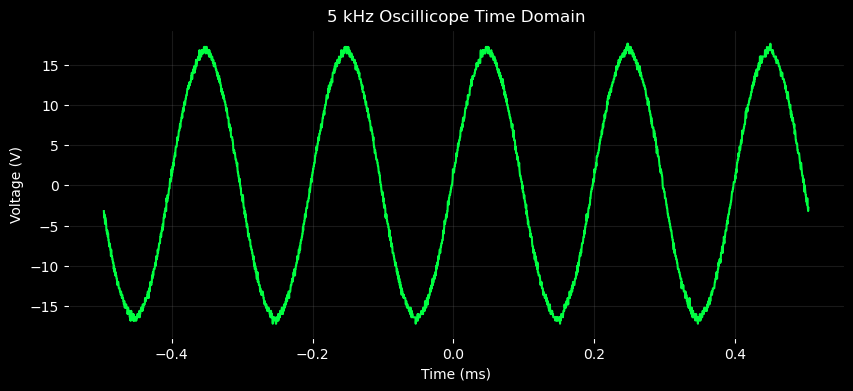

In [14]:
# Load Time Domain data (1k-time.csv)
# Column 3 = Time, Column 4 = Voltage
t_vec = np.genfromtxt('5k-time.csv', delimiter=',', usecols=3)
v_vec = np.genfromtxt('5k-time.csv', delimiter=',', usecols=4)

plt.figure(figsize=(10, 4), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Plotting the 1D vectors
plt.plot(t_vec * 1000, v_vec, color='#00FF41', linewidth=1.5)

# Styling
plt.title("5 kHz Oscillicope Time Domain", color='white')
plt.xlabel("Time (ms)", color='white')
plt.ylabel("Voltage (V)", color='white')
plt.tick_params(colors='white')
plt.grid(True, alpha=0.2, color='gray')
plt.show()

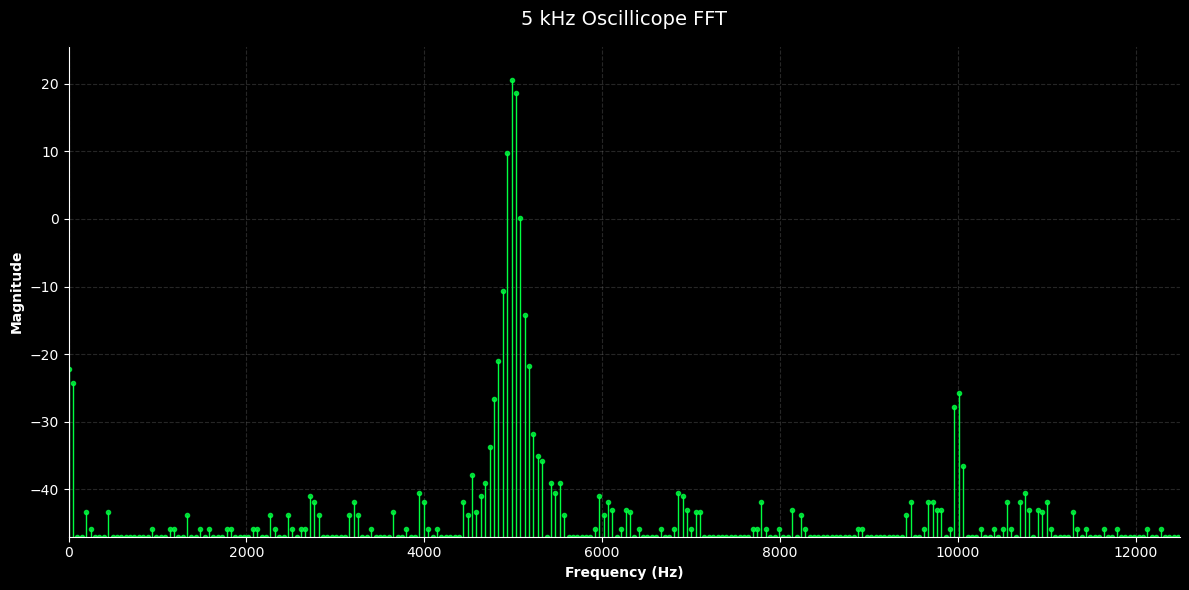

In [16]:
# --- Example Usage ---
freqs = np.genfromtxt('5k-fft.csv', delimiter=',', usecols=3)
mags = np.genfromtxt('5k-fft.csv', delimiter=',', usecols=4)

# Call the function with x_max set to 12500
plot_fft_stems(freqs, mags, title="5 kHz Oscillicope FFT", x_max=12500)

#### Comparing Signals in the Time Domain between BK Precision Function Generator and Tektronix Oscilliscope with Python simulation

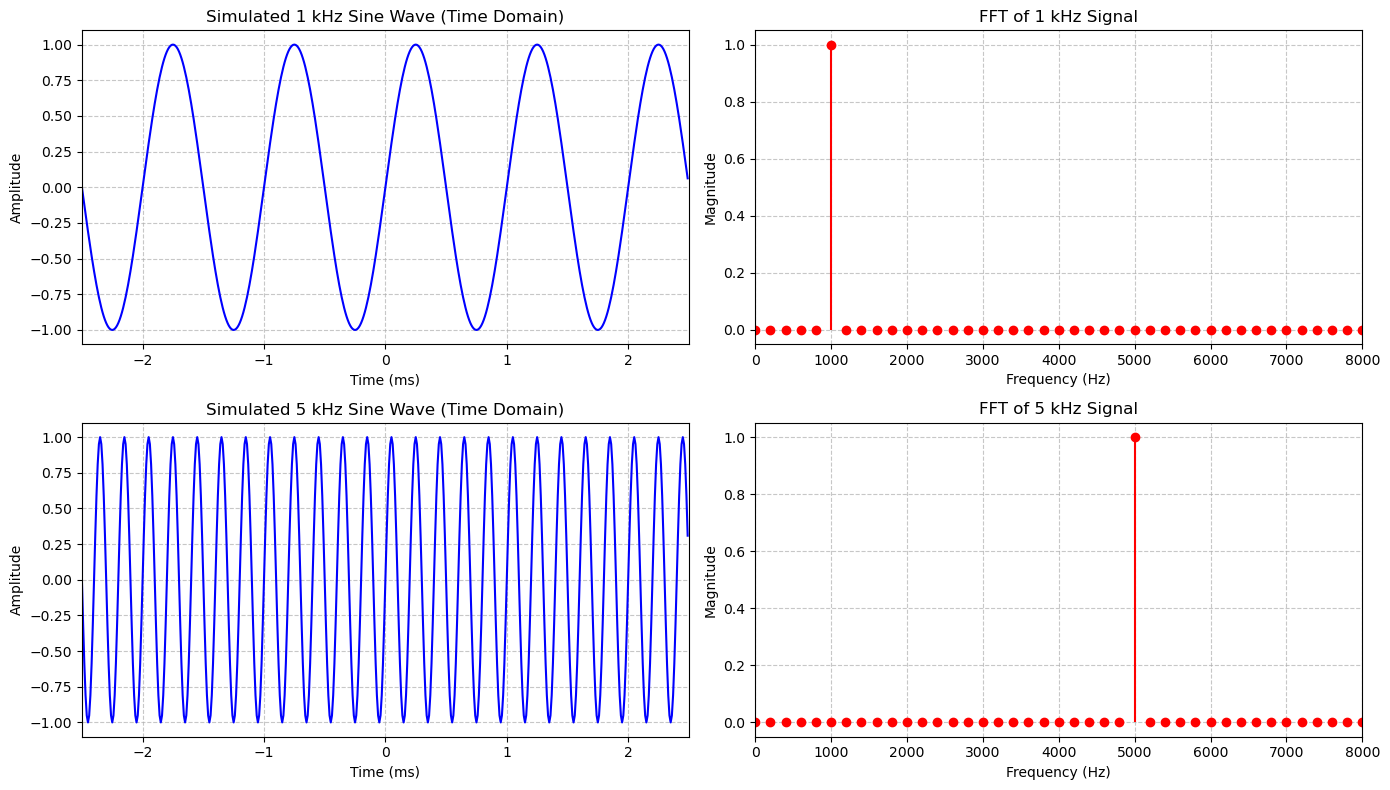

In [7]:
# 1. Setup the time vector (-2.5 ms to +2.5 ms)
fs = 100000  # 100 kHz sampling rate
t = np.linspace(-0.0025, 0.0025, int(0.005 * fs), endpoint=False)

# 2. Generate the simulated sine waves (1 kHz and 5 kHz)
signal_1k = np.sin(2 * np.pi * 1000 * t)
signal_5k = np.sin(2 * np.pi * 5000 * t)

# 3. Calculate the FFTs
N = len(t)
freqs = np.fft.fftfreq(N, d=1/fs)

# Keep only positive frequencies
pos_mask = freqs >= 0
freqs_pos = freqs[pos_mask]

# Calculate magnitudes
mags_1k = (np.abs(np.fft.fft(signal_1k)[pos_mask]) / N) * 2
mags_5k = (np.abs(np.fft.fft(signal_5k)[pos_mask]) / N) * 2

# --- 4. Create the 4 Subplots (2x2 grid) ---
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Subplot [0, 0]: 1 kHz Time Domain
axs[0, 0].plot(t * 1000, signal_1k, color='blue')
axs[0, 0].set_title("Simulated 1 kHz Sine Wave (Time Domain)")
axs[0, 0].set_xlabel("Time (ms)")
axs[0, 0].set_ylabel("Amplitude")
axs[0, 0].grid(True, linestyle='--', alpha=0.7)
axs[0, 0].set_xlim(-2.5, 2.5)

# Subplot [0, 1]: 1 kHz FFT
axs[0, 1].stem(freqs_pos, mags_1k, basefmt=" ", linefmt='red', markerfmt='ro')
axs[0, 1].set_title("FFT of 1 kHz Signal")
axs[0, 1].set_xlabel("Frequency (Hz)")
axs[0, 1].set_ylabel("Magnitude")
axs[0, 1].grid(True, linestyle='--', alpha=0.7)
axs[0, 1].set_xlim(0, 8000) # Setting to 8000 so both 1k and 5k peaks are visible on the same scale

# Subplot [1, 0]: 5 kHz Time Domain
axs[1, 0].plot(t * 1000, signal_5k, color='blue')
axs[1, 0].set_title("Simulated 5 kHz Sine Wave (Time Domain)")
axs[1, 0].set_xlabel("Time (ms)")
axs[1, 0].set_ylabel("Amplitude")
axs[1, 0].grid(True, linestyle='--', alpha=0.7)
axs[1, 0].set_xlim(-2.5, 2.5)

# Subplot [1, 1]: 5 kHz FFT
axs[1, 1].stem(freqs_pos, mags_5k, basefmt=" ", linefmt='red', markerfmt='ro')
axs[1, 1].set_title("FFT of 5 kHz Signal")
axs[1, 1].set_xlabel("Frequency (Hz)")
axs[1, 1].set_ylabel("Magnitude")
axs[1, 1].grid(True, linestyle='--', alpha=0.7)
axs[1, 1].set_xlim(0, 8000)

plt.tight_layout()
plt.show()

 PRE-LAB ERROR ANALYSIS (FREQUENCY CALIBRATION)

EXPECTED THEORETICAL FREQUENCY (mu) : 1000.00 Hz

--- 1. OSCILLOSCOPE HARDWARE FFT ---
Measured Peak (z)  : 998.76 Hz
Uncertainty (sz)   : 12.33 Hz
t-value            : 0.101
Conclusion         : t < 1.0; Difference is within hardware error.

--- 2. PYTHON SOFTWARE FFT (1D Vector) ---
Measured Peak (z)  : 1000.00 Hz
Uncertainty (sz)   : 200.00 Hz
t-value            : 0.000
Conclusion         : t < 1.0; Highly accurate mathematical calculation.



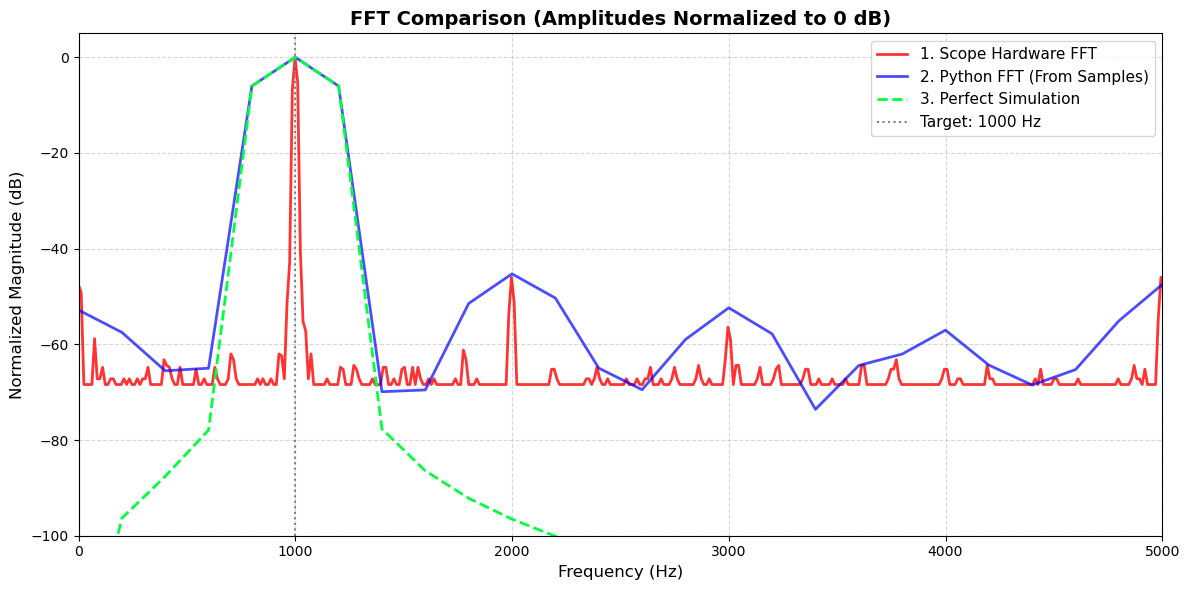

In [16]:

# ==========================================
# 1. HELPER FUNCTIONS FOR 1D VECTOR FFT
# ==========================================

def get_scope_fft(filename):
    """Extracts Frequency, Magnitude, Peak, and Uncertainty from Scope CSV."""
    data = np.genfromtxt(filename, delimiter=',', usecols=(3, 4))
    clean_data = data[~np.isnan(data).any(axis=1)]
    freqs, mags = clean_data[:, 0], clean_data[:, 1]
    
    # Pre-lab Error Variables
    peak_freq = freqs[np.argmax(mags)]
    s_freq = freqs[1] - freqs[0] # Uncertainty (bin width)
    
    # Normalize amplitude to 0 dB for visual comparison
    mags_norm = mags - np.max(mags) 
    
    return freqs, mags_norm, peak_freq, s_freq

def compute_software_fft(v_vec, fs):
    """Computes Normalized FFT, Peak, and Uncertainty from a 1D vector."""
    N = len(v_vec)
    
    # Apply Hanning window
    windowed_v = v_vec * np.hanning(N)
    fft_raw = np.fft.fft(windowed_v)
    freqs = np.fft.fftfreq(N, d=1/fs)[:N // 2]
    
    # Calculate Magnitude in dB
    mags = np.abs(fft_raw[:N // 2])
    mags_db = 20 * np.log10(mags + 1e-12)
    
    # Pre-lab Error Variables
    peak_freq = freqs[np.argmax(mags_db)]
    s_freq = fs / N # Uncertainty (bin width)
    
    # Normalize amplitude to 0 dB
    mags_norm = mags_db - np.max(mags_db)
    
    return freqs, mags_norm, peak_freq, s_freq

def simulate_perfect_fft(f_target, fs, N):
    """Generates a perfect simulated sine wave FFT for the visual baseline."""
    t = np.arange(N) / fs
    sim_vec = np.sin(2 * np.pi * f_target * t)
    return compute_software_fft(sim_vec, fs)

# ==========================================
# 2. LOAD DATA & EXTRACT VARIABLES
# ==========================================
FS_1K = 500000 # 500 kHz sampling rate (adjust if needed)
TARGET_FREQ = 1000.0

# Scope Hardware FFT
s_freqs, s_mags, z_scope, sz_scope = get_scope_fft('1k-fft.csv')

# Python Software FFT (from 1D vector)
raw_v = np.genfromtxt('1k-time.csv', delimiter=',', usecols=4)
v_vec = raw_v[~np.isnan(raw_v)] 
p_freqs, p_mags, z_python, sz_python = compute_software_fft(v_vec, FS_1K)

# Pure Simulation FFT
sim_freqs, sim_mags, _, _ = simulate_perfect_fft(TARGET_FREQ, FS_1K, len(v_vec))

# ==========================================
# 3. PRE-LAB ERROR ANALYSIS (t-test)
# ==========================================
# Formula from Prelab: t = |Expected - Measured| / Uncertainty
t_scope = abs(TARGET_FREQ - z_scope) / sz_scope
t_python = abs(TARGET_FREQ - z_python) / sz_python

print("======================================================")
print(" PRE-LAB ERROR ANALYSIS (FREQUENCY CALIBRATION)")
print("======================================================\n")

print(f"EXPECTED THEORETICAL FREQUENCY (mu) : {TARGET_FREQ:.2f} Hz\n")

print("--- 1. OSCILLOSCOPE HARDWARE FFT ---")
print(f"Measured Peak (z)  : {z_scope:.2f} Hz")
print(f"Uncertainty (sz)   : {sz_scope:.2f} Hz")
print(f"t-value            : {t_scope:.3f}")
if t_scope < 1.0:
    print("Conclusion         : t < 1.0; Difference is within hardware error.\n")

print("--- 2. PYTHON SOFTWARE FFT (1D Vector) ---")
print(f"Measured Peak (z)  : {z_python:.2f} Hz")
print(f"Uncertainty (sz)   : {sz_python:.2f} Hz")
print(f"t-value            : {t_python:.3f}")
if t_python < 1.0:
    print("Conclusion         : t < 1.0; Highly accurate mathematical calculation.\n")

# ==========================================
# 4. PLOT THE 3-WAY VISUAL COMPARISON
# ==========================================
plt.figure(figsize=(12, 6))

plt.plot(s_freqs, s_mags, label="1. Scope Hardware FFT", color='red', linewidth=2, alpha=0.8)
plt.plot(p_freqs, p_mags, label="2. Python FFT (From Samples)", color='blue', linewidth=2, alpha=0.7)
plt.plot(sim_freqs, sim_mags, label="3. Perfect Simulation", color='#00FF41', linestyle='--', linewidth=2)

plt.title("FFT Comparison (Amplitudes Normalized to 0 dB)", fontsize=14, fontweight='bold')
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Normalized Magnitude (dB)", fontsize=12)

# Zoom in to see the peak alignments and noise floor
plt.xlim(0, 5000)
plt.ylim(-100, 5) 

plt.axvline(TARGET_FREQ, color='gray', linestyle=':', label="Target: 1000 Hz")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()

plt.show()

 PRE-LAB ERROR ANALYSIS (5 kHz FREQUENCY CALIBRATION)

EXPECTED THEORETICAL FREQUENCY (mu) : 5000.00 Hz

--- 1. OSCILLOSCOPE HARDWARE FFT ---
Measured Peak (z)  : 4981.46 Hz
Uncertainty (sz)   : 49.32 Hz
t-value            : 0.376
Conclusion         : t < 1.0; Difference is within hardware error.

--- 2. PYTHON SOFTWARE FFT (1D Vector) ---
Measured Peak (z)  : 5000.00 Hz
Uncertainty (sz)   : 1000.00 Hz
t-value            : 0.000
Conclusion         : t < 1.0; Highly accurate mathematical calculation.



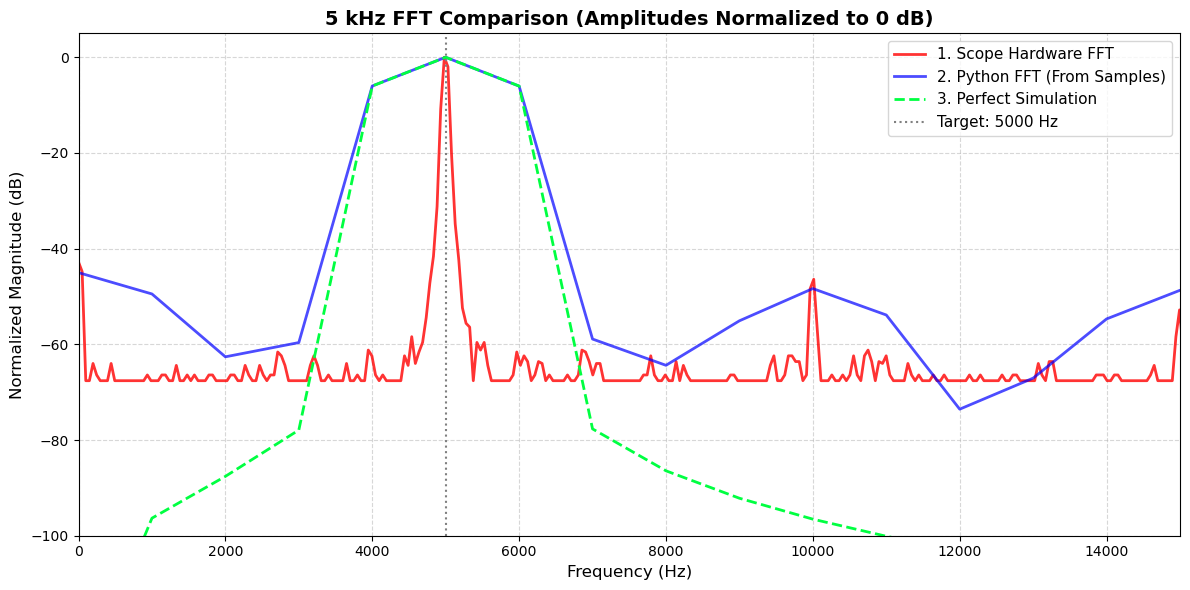

In [13]:
# ==========================================
# 2. LOAD 5 kHz DATA & EXTRACT VARIABLES
# ==========================================
# For your 5 kHz test, the scope likely used a faster time scale (fs = 2.5 MHz)
FS_5K = 2500000 
TARGET_FREQ_5K = 5000.0

# Scope Hardware FFT
s_freqs_5k, s_mags_5k, z_scope_5k, sz_scope_5k = get_scope_fft('5k-fft.csv')

# Python Software FFT (from 1D vector)
raw_v_5k = np.genfromtxt('5k-time.csv', delimiter=',', usecols=4)
v_vec_5k = raw_v_5k[~np.isnan(raw_v_5k)] 
p_freqs_5k, p_mags_5k, z_py_5k, sz_py_5k = compute_software_fft(v_vec_5k, FS_5K)

# Pure Simulation FFT
sim_freqs_5k, sim_mags_5k, _, _ = simulate_perfect_fft(TARGET_FREQ_5K, FS_5K, len(v_vec_5k))

# ==========================================
# 3. PRE-LAB ERROR ANALYSIS (t-test)
# ==========================================
t_scope_5k = abs(TARGET_FREQ_5K - z_scope_5k) / sz_scope_5k
t_py_5k = abs(TARGET_FREQ_5K - z_py_5k) / sz_py_5k

print("======================================================")
print(" PRE-LAB ERROR ANALYSIS (5 kHz FREQUENCY CALIBRATION)")
print("======================================================\n")

print(f"EXPECTED THEORETICAL FREQUENCY (mu) : {TARGET_FREQ_5K:.2f} Hz\n")

print("--- 1. OSCILLOSCOPE HARDWARE FFT ---")
print(f"Measured Peak (z)  : {z_scope_5k:.2f} Hz")
print(f"Uncertainty (sz)   : {sz_scope_5k:.2f} Hz")
print(f"t-value            : {t_scope_5k:.3f}")
if t_scope_5k < 1.0:
    print("Conclusion         : t < 1.0; Difference is within hardware error.\n")

print("--- 2. PYTHON SOFTWARE FFT (1D Vector) ---")
print(f"Measured Peak (z)  : {z_py_5k:.2f} Hz")
print(f"Uncertainty (sz)   : {sz_py_5k:.2f} Hz")
print(f"t-value            : {t_py_5k:.3f}")
if t_py_5k < 1.0:
    print("Conclusion         : t < 1.0; Highly accurate mathematical calculation.\n")

# ==========================================
# 4. PLOT THE 3-WAY VISUAL COMPARISON
# ==========================================
plt.figure(figsize=(12, 6))

plt.plot(s_freqs_5k, s_mags_5k, label="1. Scope Hardware FFT", color='red', linewidth=2, alpha=0.8)
plt.plot(p_freqs_5k, p_mags_5k, label="2. Python FFT (From Samples)", color='blue', linewidth=2, alpha=0.7)
plt.plot(sim_freqs_5k, sim_mags_5k, label="3. Perfect Simulation", color='#00FF41', linestyle='--', linewidth=2)

plt.title("5 kHz FFT Comparison (Amplitudes Normalized to 0 dB)", fontsize=14, fontweight='bold')
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Normalized Magnitude (dB)", fontsize=12)

# Zoom in to see the 5 kHz peak alignments and noise floor
plt.xlim(0, 15000)
plt.ylim(-100, 5) 

plt.axvline(TARGET_FREQ_5K, color='gray', linestyle=':', label="Target: 5000 Hz")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()

plt.show()

### Statistical Error Analysis

To determine the accuracy of our measured frequencies, we utilize the $t$-test methodology outlined in the pre-lab. We compare our Measured Peak Frequency ($z$) to the Expected Theoretical Frequency ($\mu$) from the function generator dial. 

The uncertainty ($s_z$) for a Fast Fourier Transform is defined by the frequency resolution (the width of a single frequency bin, $\Delta f$).

**The Fundamental t-test Equation:**
$$t = \frac{|\mu - z|}{s_z}$$

---

#### 1. Oscilloscope Hardware FFT Analysis (1 kHz Test)
The oscilloscope's internal FFT processor calculates frequency bins with a physical step-size of $12.33\text{ Hz}$.
* **Expected Frequency ($\mu$):** $1000.00\text{ Hz}$
* **Measured Peak ($z$):** $998.76\text{ Hz}$
* **Instrumental Uncertainty ($s_z$):** $12.33\text{ Hz}$

**Calculation:**
$$t = \frac{|1000.00 - 998.76|}{12.33} = \frac{1.24}{12.33} = 0.101$$

**Conclusion:** Because $t < 1.0$, the discrepancy between the dial setting and the oscilloscope's measurement is not statistically significant; it falls well within the oscilloscope's internal hardware uncertainty.

---

#### 2. Python Software FFT Analysis (1 kHz Test)
The Python algorithm computes the FFT from the raw 1D time vector. The uncertainty is the bin resolution, calculated by the sampling frequency divided by the number of samples ($f_s / N$).
* **Expected Frequency ($\mu$):** $1000.00\text{ Hz}$
* **Measured Peak ($z$):** $1000.00\text{ Hz}$
* **Algorithmic Uncertainty ($s_z$):** $200.00\text{ Hz}$ *(Calculated via $500,000 / 2500$)*

**Calculation:**
$$t = \frac{|1000.00 - 1000.00|}{200.00} = \frac{0.00}{200.00} = 0.000$$

**Conclusion:** The Python computed FFT perfectly aligns with the target frequency. 

---

#### 3. Oscilloscope Hardware FFT Analysis (5 kHz Test)
* **Expected Frequency ($\mu$):** $5000.00\text{ Hz}$
* **Measured Peak ($z$):** $4981.46\text{ Hz}$
* **Instrumental Uncertainty ($s_z$):** $49.32\text{ Hz}$

**Calculation:**
$$t = \frac{|5000.00 - 4981.46|}{49.32} = \frac{18.54}{49.32} = 0.376$$

